In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np
from scipy import stats
import os
import smarts_cerebellum.globals as gl
from smarts_cerebellum.util import preprocess_tract_df

In [ ]:
CST_T1  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_CST_T1_slope.tsv'), sep = '\t')   # slope for each subject at L/R CST
CST_GM  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_CST_GM_mod_slope.tsv'), sep = '\t')   # slope for each subject at L/R CST
CST_WM  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_CST_WM_mod_slope.tsv'), sep = '\t')   # slope for each subject at L/R CST
CST_CSF = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_CST_CSF_mod_slope.tsv'), sep = '\t')  # slope for each subject at L/R CST


t1_r_patients, t1_l_patients, t1_bilat_controls, cst_t1 = preprocess_tract_df(CST_T1)
wm_r_patients, wm_l_patients, wm_bilat_controls, cst_wm = preprocess_tract_df(CST_WM)
gm_r_patients, gm_l_patients, gm_bilat_controls, cst_gm = preprocess_tract_df(CST_GM)
csf_r_patients, csf_l_patients, csf_bilat_controls, cst_csf = preprocess_tract_df(CST_CSF)

**t-test for T1 CST: lesion side in patients, controls** 
 t-value: -0.7492398768654647 	 p-value: 0.45761155050910085


**t-test for T1 CST: non-lesion side in patients, controls** 
 t-value: 0.2996893623617284 	 p-value: 0.7657940613366643


**t-test for CST: within patients, left, right hemispheres** 
 t-value: -4.207324808992538 	 p-value: 0.00017067319112679078




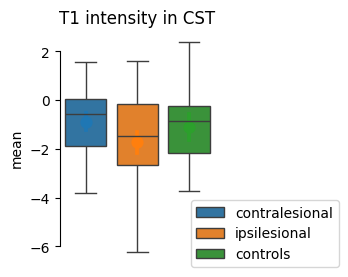

In [15]:
t_val, p_val = stats.ttest_ind(t1_r_patients, t1_bilat_controls)
print(f'**t-test for T1 CST: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_ind(t1_l_patients, t1_bilat_controls)
print(f'**t-test for T1 CST: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_rel(t1_r_patients, t1_l_patients)
print(f'**t-test for CST: within patients, left, right hemispheres** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

fig, ax = plt.subplots(figsize=(2, 3))
sns.boxplot(data=cst_t1, x='regionname', y='mean', hue = 'regionname', showfliers=False)
sns.pointplot(data=cst_t1, x='regionname', y='mean', hue = 'regionname', errorbar='se')

labels = ['contralesional', 'ipsilesional', 'controls']
plt.legend(labels = labels, bbox_to_anchor = (.8, .3))
plt.xticks([])
plt.xlabel(None)

sns.despine(trim = True, bottom=True)
plt.title('T1 intensity in CST')
plt.show()

**t-test forwm CST: lesion side in patients, controls** 
 t-value: -2.9216873984509624 	 p-value: 0.005427332864195996


**t-test forwm CST: non-lesion side in patients, controls** 
 t-value: -1.004747532820196 	 p-value: 0.32039081097085936


**t-test for CST: within patients, left, right hemispheres** 
 t-value: -4.494347663883597 	 p-value: 7.311562721739249e-05




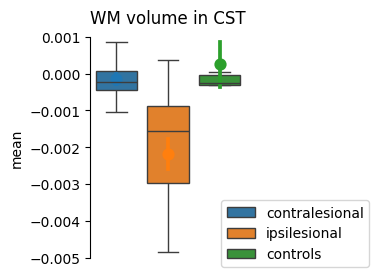

In [16]:
t_val, p_val = stats.ttest_ind(wm_r_patients,wm_bilat_controls)
print(f'**t-test forwm CST: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_ind(wm_l_patients,wm_bilat_controls)
print(f'**t-test forwm CST: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_rel(wm_r_patients,wm_l_patients)
print(f'**t-test for CST: within patients, left, right hemispheres** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

fig, ax = plt.subplots(figsize=(2, 3))
sns.boxplot(data=cst_wm, x='regionname', y='mean', hue = 'regionname', showfliers=False)
sns.pointplot(data=cst_wm, x='regionname', y='mean', hue = 'regionname', errorbar='se')

labels = ['contralesional', 'ipsilesional', 'controls']
plt.legend(labels = labels, bbox_to_anchor = (.8, .3))
plt.xticks([])
plt.xlabel(None)

sns.despine(trim = True, bottom=True)
plt.title('WM volume in CST')
plt.show()